<div align="center">

# Prueba 1er Parcial

### 30 Septiembre de 2026

<br>

<img src="img/logoitqv1.jpg" width="650">

<br><br>

</div>

# Prueba

<div align="center">

<img src="img/python_logo.png" width="550">

</div>

<div align="left">

### Eric Campoverde, Cristian Arias

<a href="https://github.com/EricJordy/MachineLearning2.git">Repositorio Git</a>

</div>

<hr style="height:3px;border:none;background:#b30000;">


In [1]:
import numpy as np # Importa NumPy, una librería para trabajar con arreglos y operaciones numéricas.

from math import sqrt # Permite utilizar la función sqrt() para calcular raíces cuadradas

from pprint import pprint # Permite mostrar diccionarios y resultados de forma ordenada

# Importa herramientas de Scikit-Learn. ...datasets: conjuntos de datos -linear_model: modelos de regresión lineal -metrics: métricas para evaluar el modelo.
from sklearn import datasets, linear_model, metrics

from sklearn.dummy import DummyRegressor # Importa un modelo que sirve como referencia o modelo base.

# Importa herramientas para dividir los datos y realizar validación cruzada
from sklearn.model_selection import ( cross_validate, KFold, cross_val_predict, train_test_split, cross_val_score)

from sklearn import preprocessing # Importa herramientas para realizar transformaciones de los datos

from sklearn.metrics import make_scorer, mean_squared_error # Importa herramientas para calcular métricas

import matplotlib.pyplot as plt # Importa Matplotlib para realizar gráficos

In [ ]:
pip install kagglehub

In [2]:
import kagglehub

path = kagglehub.dataset_download(
    "mirichoi0218/insurance",
    output_dir="./data"
) 

print("Dataset descargado en:", path)

C:\Users\ericj\anaconda3\envs\machine2026\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset descargado en: ./data


In [5]:
# Carga el archivo insurance.csv

# delimiter="," nos indica que las columnas están separadas por comas
# dtype=str nos carga inicialmente los datos como texto
# skip_header=1 ignora la primera fila de nombres
datos = np.genfromtxt(
    "./data/insurance.csv", delimiter=",", dtype=str, skip_header=1)

# Muestra las dimensiones del dataset
print("Dimensiones de los datos:", np.shape(datos))

Dimensiones de los datos: (1338, 7)


In [6]:
# Define los nombres de las columnas
nombres = [
    "age", "sex", "bmi", "children", "smoker", "region", "charges"]

# Muestra los nombres
print("Variables:")
print(nombres)

Variables:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [7]:
# Muestra los primeros 5 registros.
print("Primeros 5 registros:")
print(datos[:5])

Primeros 5 registros:
[['19' 'female' '27.9' '0' 'yes' 'southwest' '16884.924']
 ['18' 'male' '33.77' '1' 'no' 'southeast' '1725.5523']
 ['28' 'male' '33' '3' 'no' 'southeast' '4449.462']
 ['33' 'male' '22.705' '0' 'no' 'northwest' '21984.47061']
 ['32' 'male' '28.88' '0' 'no' 'northwest' '3866.8552']]


In [8]:
# Obtiene la cantidad de registros
numero_registros = datos.shape[0]

# Obtiene la cantidad de variables
numero_variables = datos.shape[1]

# Muestra la cantidad de registros
print("Número de registros:", numero_registros)

# Muestra la cantidad de variables
print("Número de variables:", numero_variables)


Número de registros: 1338
Número de variables: 7


**EDA y calidad de los datos**

In [9]:
# Busca valores vacíos en el dataset
valores_vacios = np.char.str_len(
    np.char.strip(datos)) == 0

# Cuenta los valores vacíos por columna
cantidad_vacios = valores_vacios.sum(axis=0)

# Muestra los resultados
print("Valores vacíos por variable:")

# Recorre cada variable y su cantidad de valores vacíos
for nombre, cantidad in zip(nombres, cantidad_vacios):

# Muestra el resultado
    print(nombre, ":", cantidad)


Valores vacíos por variable:
age : 0
sex : 0
bmi : 0
children : 0
smoker : 0
region : 0
charges : 0


In [10]:
# Convierte age de texto a número
age = datos[:, 0].astype(float)

# Convierte bmi de texto a número
bmi = datos[:, 2].astype(float)

# Convierte children de texto a número
children = datos[:, 3].astype(float)

# Convierte charges de texto a número
charges = datos[:, 6].astype(float)

In [11]:
# Calcula el mínimo de age
print("AGE")
print("Mínimo:", np.min(age))

# Calcula el máximo de age
print("Máximo:", np.max(age))

# Calcula el promedio de age
print("Promedio:", np.mean(age))

#..
# Calcula estadísticas de BMI
print("\nBMI")
print("Mínimo:", np.min(bmi))
print("Máximo:", np.max(bmi))
print("Promedio:", np.mean(bmi))

#..
# Calcula estadísticas de children
print("\nCHILDREN")
print("Mínimo:", np.min(children))
print("Máximo:", np.max(children))
print("Promedio:", np.mean(children))

#..
# Calcula estadísticas de charges.
print("\nCHARGES")
print("Mínimo:", np.min(charges))
print("Máximo:", np.max(charges))
print("Promedio:", np.mean(charges))

AGE
Mínimo: 18.0
Máximo: 64.0
Promedio: 39.20702541106129

BMI
Mínimo: 15.96
Máximo: 53.13
Promedio: 30.66339686098655

CHILDREN
Mínimo: 0.0
Máximo: 5.0
Promedio: 1.0949177877429

CHARGES
Mínimo: 1121.8739
Máximo: 63770.42801
Promedio: 13270.422265141257


In [12]:
# Cuenta las personas fumadoras
fumadores = np.sum(datos[:, 4] == "yes")

# Cuenta las personas no fumadoras
no_fumadores = np.sum(datos[:, 4] == "no")

# Muestra los resultados
print("Fumadores:", fumadores)
print("No fumadores:", no_fumadores)

Fumadores: 274
No fumadores: 1064


In [13]:
# Cuenta personas de cada región
northeast = np.sum(datos[:, 5] == "northeast")
northwest = np.sum(datos[:, 5] == "northwest")
southeast = np.sum(datos[:, 5] == "southeast")
southwest = np.sum(datos[:, 5] == "southwest")

# Muestra los resultados
print("Northeast:", northeast)
print("Northwest:", northwest)
print("Southeast:", southeast)
print("Southwest:", southwest)

Northeast: 324
Northwest: 325
Southeast: 364
Southwest: 325


**Detección de outliers**

In [14]:
# Calcula el primer cuartil
Q1 = np.percentile(charges, 25)

# Calcula el tercer cuartil
Q3 = np.percentile(charges, 75)

# Calcula el rango intercuartílico.
IQR = Q3 - Q1

# Calcula el límite inferior
limite_inferior = Q1 - 1.5 * IQR

# Calcula el límite superior
limite_superior = Q3 + 1.5 * IQR

# Muestra los resultados
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)


Q1: 4740.28715
Q3: 16639.912515
IQR: 11899.625365
Límite inferior: -13109.1508975
Límite superior: 34489.350562499996


In [15]:
# Identifica los valores inferiores al límite
outliers_inferiores = charges < limite_inferior

# Identifica los valores superiores al límite
outliers_superiores = charges > limite_superior

# Une ambos tipos de outliers
outliers = outliers_inferiores | outliers_superiores

# Cuenta los valores atípicos
cantidad_outliers = np.sum(outliers)

# Muestra la cantidad
print("Cantidad de outliers:", cantidad_outliers)

Cantidad de outliers: 139


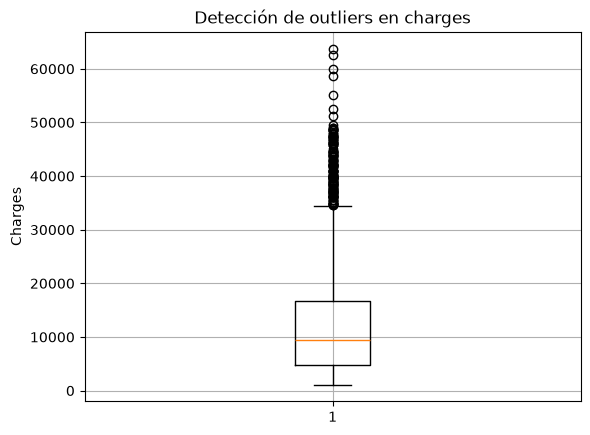

In [16]:
# Crea una figura
plt.figure()

# Crea un diagrama de caja
plt.boxplot(charges)

# Coloca el nombre del eje Y
plt.ylabel("Charges")

# Coloca el título
plt.title("Detección de outliers en charges")

# Activa la cuadrícula
plt.grid()

# Muestra el gráfico
plt.show()

**Preparación de variables**

In [17]:
# Convierte male en 1 y female en 0.
sex = np.where(
    datos[:, 1] == "male", 1, 0)

In [18]:
# Convierte yes en 1 y no en 0.
smoker = np.where(
    datos[:, 4] == "yes", 1, 0)

In [19]:
# Crea una variable para southeast.
region_southeast = np.where(
    datos[:, 5] == "southeast", 1, 0)

# Crea una variable para southwest.
region_southwest = np.where(
    datos[:, 5] == "southwest", 1, 0)

# Crea una variable para northwest.
region_northwest = np.where(
    datos[:, 5] == "northwest", 1, 0)

**Normalización - estandarización**

In [20]:
# Construye la matriz X.
X = np.column_stack((
    age, sex, bmi, children, smoker, region_southeast, region_southwest, region_northwest))

# Define y como la variable que queremos predecir.
y = charges

# Muestra las dimensiones de X.
print("Dimensiones de X:", np.shape(X))

# Muestra las dimensiones de y.
print("Dimensiones de y:", np.shape(y))

Dimensiones de X: (1338, 8)
Dimensiones de y: (1338,)


In [21]:
# Divide los datos en entrenamiento y prueba.
X_training, X_testing, y_training, y_testing = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Crea el estandarizador.
standardizer = preprocessing.StandardScaler()

# Aprende la media y desviación de los datos de entrenamiento.
stdr_trained = standardizer.fit(X_training)

# Estandariza los datos de entrenamiento.
X_stdr = stdr_trained.transform(X_training)

# Estandariza los datos de prueba.
X_test_stdr = stdr_trained.transform(X_testing)

# Muestra las dimensiones.
print("X_training:", np.shape(X_training))
print("X_stdr:", np.shape(X_stdr))

X_training: (1070, 8)
X_stdr: (1070, 8)


In [22]:
# Selecciona todos los atributos.
X_selected = X_stdr

# Muestra la cantidad de atributos.
print("Cantidad de atributos seleccionados:", X_selected.shape[1])

Cantidad de atributos seleccionados: 8


In [23]:
# Define las métricas de evaluación.
metricas = {
    # Error absoluto medio.
    'MAE': 'neg_mean_absolute_error',

    # Raíz del error cuadrático medio.
    'RMSE': make_scorer(
        lambda y, y_pred:
        sqrt(
            metrics.mean_squared_error( y, y_pred)), greater_is_better=False ),

    # Error porcentual absoluto medio.
    'MAPE': make_scorer(
        lambda y, y_pred:
        np.mean(
            np.abs((y - y_pred) / y)) * 100,
        greater_is_better=False),

    # Coeficiente de determinación.
    'R2': 'r2'
}


**Entrenamiento mediante Regresión Lineal**

In [24]:
# Crea el modelo de regresión lineal.
reg = linear_model.LinearRegression( fit_intercept=True )

In [25]:
# Realiza validación cruzada con 5 grupos.
cross_val_results = cross_validate(reg, X_selected, y_training,
    cv=KFold( n_splits=5, shuffle=True, random_state=42),
    scoring=metricas)

# Muestra los resultados.
pprint(cross_val_results)

{'fit_time': array([0.01630235, 0.01012564, 0.00501943, 0.00399852, 0.00716805]),
 'score_time': array([0.00788498, 0.00836158, 0.00866795, 0.00826716, 0.0079968 ]),
 'test_MAE': array([-4486.4790963 , -4516.76593661, -3879.99770641, -4253.01663089,
       -4038.65847917]),
 'test_MAPE': array([-39.99330202, -42.43681525, -46.24073003, -41.66040371,
       -41.71812557]),
 'test_R2': array([0.72680298, 0.70644838, 0.77471673, 0.70919693, 0.77709874]),
 'test_RMSE': array([-6602.03950217, -6528.25221873, -5437.12516438, -6427.86067043,
       -5621.49155797])}


In [26]:
# Entrena el modelo utilizando todos
# los datos de entrenamiento.
model = reg.fit( X_selected, y_training)

# Obtiene los coeficientes.
w = model.coef_

# Muestra los coeficientes.
print("Model coeficients:")
print(w)

# Obtiene el término independiente.
w_0 = model.intercept_

# Muestra el término independiente.
print("\nTérmino independiente:", w_0)

Model coeficients:
[ 3.61497541e+03 -9.29310107e+00  2.03622812e+03  5.16890247e+02
  9.55848141e+03 -2.90157047e+02 -3.49110678e+02 -1.58140981e+02]

Término independiente: 13346.08973636448


**Evaluación**

In [27]:
# Realiza las predicciones del conjunto de prueba.
y_pred_test = model.predict( X_test_stdr)

In [28]:
# Calcula MAE.
MAE = metrics.mean_absolute_error( y_testing, y_pred_test)

# Calcula MSE.
MSE = metrics.mean_squared_error( y_testing, y_pred_test)

# Calcula RMSE.
RMSE = sqrt(MSE)

# Calcula MAPE.
MAPE = metrics.mean_absolute_percentage_error( y_testing, y_pred_test)

# Calcula R2.
R2 = metrics.r2_score( y_testing, y_pred_test)

# Muestra MAE.
print("MAE: %.4f" % MAE)

# Muestra MSE.
print("MSE: %.4f" % MSE)

# Muestra RMSE.
print("RMSE: %.4f" % RMSE)

# Muestra MAPE.
print("MAPE: %.4f" % MAPE)

# Muestra R2.
print("R2: %.4f" % R2)

MAE: 4181.1945
MSE: 33596915.8514
RMSE: 5796.2847
MAPE: 0.4689
R2: 0.7836


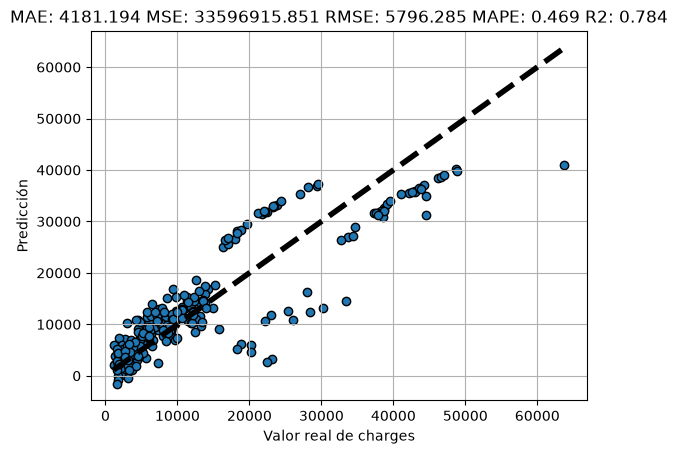

In [29]:
# Crea la figura.
fig, ax = plt.subplots()

# Compara valores reales contra valores predichos.
ax.scatter( y_testing, y_pred_test, edgecolors=(0, 0, 0) )

# Dibuja la línea de predicción perfecta.
ax.plot(
    [y.min(), y.max()], [y.min(), y.max()], 'k--', lw=4 )

# Nombre del eje X.
ax.set_xlabel( 'Valor real de charges' )

# Nombre del eje Y.
ax.set_ylabel( 'Predicción')

# Coloca las métricas en el título.
plt.title( "MAE: %.3f MSE: %.3f RMSE: %.3f MAPE: %.3f R2: %.3f"
    % ( MAE, MSE, RMSE, MAPE, R2) )

# Activa la cuadrícula.
plt.grid()

# Muestra el gráfico.
plt.show()

In [30]:
# Crea una nueva observación.
#
# El orden debe ser igual al utilizado en X.
nuevo = np.array([
    [
        35,      # age
        1,       # sex: male
        28.5,    # bmi
        2,       # children
        0,       # smoker: no
        1,       # southeast
        0,       # southwest
        0        # northwest
    ]
])

# Muestra los datos nuevos.
print("Nueva observación:")
print(nuevo)

Nueva observación:
[[35.   1.  28.5  2.   0.   1.   0.   0. ]]


In [31]:
# Estandariza el nuevo dato.
nuevo_stdr = stdr_trained.transform(nuevo)

In [32]:
# Predice los gastos médicos.
nueva_prediccion = model.predict( nuevo_stdr)

# Muestra el resultado.
print( "Gasto médico estimado: $%.2f" % nueva_prediccion[0])


Gasto médico estimado: $6844.17
